In [2]:
!pip install denoising_diffusion_pytorch

from denoising_diffusion_pytorch.classifier_free_guidance import Unet, GaussianDiffusion
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torchvision.utils import save_image
from tqdm import tqdm
import numpy as np
import os
import pandas as pd
import random
import shutil
import torch
import zipfile
import tarfile
import glob
import os
import json 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 3.1 MB/s eta 0:00:00


In [3]:
tgz_path = '/kaggle/input/datasets/tinasikhbse/cartoons-100k/cartoonset100k.tgz'
extract_to = '/kaggle/working/'

print("Extracting...")
with tarfile.open(tgz_path, 'r:gz') as tar:
    tar.extractall(extract_to)
print("✅ Done!")

records = []
for subfolder in sorted(os.listdir(os.path.join(extract_to, "cartoonset100k"))):
    subfolder_path = os.path.join(extract_to, "cartoonset100k", subfolder)
    if not os.path.isdir(subfolder_path):
        continue
    for csv_path in sorted(glob.glob(os.path.join(subfolder_path, "cs*.csv"))):
        img_id = os.path.splitext(os.path.basename(csv_path))[0]
        img_path = os.path.join(subfolder_path, img_id + ".png")
        df_csv = pd.read_csv(csv_path, header=None, names=["feature", "value", "n_categories"])
        row = {"id": img_id, "img_path": img_path}
        for _, r in df_csv.iterrows():
            row[r["feature"]] = int(r["value"])
        records.append(row)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} images, {len(df.columns)-2} features")
print(df.head())

Extracting...


/tmp/ipykernel_55/2208797311.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_to)


✅ Done!
Loaded 100000 images, 18 features
                       id                                           img_path  \
0  cs11502169095236683120  /kaggle/working/cartoonset100k/0/cs11502169095...   
1  cs11502298889929094331  /kaggle/working/cartoonset100k/0/cs11502298889...   
2  cs11502404786906647764  /kaggle/working/cartoonset100k/0/cs11502404786...   
3  cs11502407216397343631  /kaggle/working/cartoonset100k/0/cs11502407216...   
4  cs11502919926067511421  /kaggle/working/cartoonset100k/0/cs11502919926...   

   eye_angle  eye_lashes  eye_lid  chin_length  eyebrow_weight  eyebrow_shape  \
0          2           1        1            0               0              0   
1          1           0        0            0               0              2   
2          1           1        1            0               1              7   
3          0           1        0            1               0              5   
4          2           0        1            0               0          

In [4]:
df['has_beard']   = (df['facial_hair'] != 14).astype(int)

df['has_glasses'] = (df['glasses'] != 11).astype(int)

df = df[df['has_beard'] == 0]
df = df[df['has_glasses'] == 0]


hair_color_map = {
    0: 'blonde',
    1: 'none',
    2: 'none',
    3: 'none',
    4: 'none',
    5: 'none',
    6: 'dark',
    7: 'none',
    8: 'none',
    9: 'none',
}
df['hair_color_label'] = df['hair_color'].map(hair_color_map)

df = df[df['hair_color_label'] != "none"]

In [5]:
df['class'] = df['hair_color_label']
print(df['class'].value_counts().sort_index())

class
blonde    2519
dark      2398
Name: count, dtype: int64


In [6]:
df = df[['id', 'class', 'has_beard', 'has_glasses', 'hair_color_label']]
df.head()

,id,class,has_beard,has_glasses,hair_color_label
10,cs11503401209912824642,blonde,0,0,blonde
28,cs11506065483702932238,dark,0,0,dark
30,cs11506615688397828623,dark,0,0,dark
37,cs11508106982004131726,blonde,0,0,blonde
93,cs11516022177130938215,blonde,0,0,blonde


In [7]:
# Set up paths
def find_img_path(img_id):
    for subfolder in range(10):
        path = Path(extract_to) / "cartoonset100k" / str(subfolder) / f"{img_id}.png"
        if path.exists():
            return str(path)
    return None

df['img_path'] = df['id'].apply(find_img_path)
print(df['img_path'].head())


folder_path = Path(extract_to, "cartoonset100k")
output_dir  = Path('/kaggle/working/images_by_class')
output_dir.mkdir(parents=True, exist_ok=True)

print("Available classes:")
print(df['class'].value_counts().sort_index())
print(f"\nTotal classes: {df['class'].nunique()}")

def convert_and_save(source_path, dest_path):
    try:
        img = Image.open(source_path)
        if img.mode == 'P':
            img = img.convert('RGBA')
        if img.mode == 'RGBA':
            background = Image.new('RGB', img.size, (255, 255, 255))
            background.paste(img, mask=img.split()[3])
            img = background
        elif img.mode != 'RGB':
            img = img.convert('RGB')
        img.save(dest_path, 'PNG')
        return True
    except Exception as e:
        print(f"Failed to convert {Path(source_path).name}: {e}")
        return False

print("\n..Converting and organizing images...\n")
for class_id in sorted(df['class'].unique()):
    class_folder = output_dir / str(class_id)
    class_folder.mkdir(exist_ok=True)
    
    subset = df[df['class'] == class_id]
    
    copied = 0
    failed = 0
    
    for _, r in subset.iterrows():
        source_file = Path(r['img_path'])  # already has correct subfolder path
        dest_file   = class_folder / f"{r['id']}.png"
        
        if source_file.exists():
            if convert_and_save(source_file, dest_file):
                copied += 1
        else:
            failed += 1
    
    row = subset.iloc[0]
    label = f"glasses={row['has_glasses']} hair={row['hair_color_label']}"
    status = f"✓ class {class_id} ({label:<30}) {copied:>5} images"
    if failed > 0:
        status += f" ({failed} missing)"
    print(status)

print(f"\n✅ Done! Images organized in: {output_dir}")

print("\n...Verifying image modes...")
mode_counts = {}
for img_path in output_dir.rglob('*.png'):
    img = Image.open(img_path)
    mode_counts[img.mode] = mode_counts.get(img.mode, 0) + 1
    img.close()

print("Image modes found:")
for mode, count in sorted(mode_counts.items()):
    print(f"  {mode}: {count} images")

if 'P' in mode_counts:
    print("⚠️ Still have palette images — check conversion logic")
else:
    print("✅ All images converted successfully!")

10    /kaggle/working/cartoonset100k/0/cs11503401209...
28    /kaggle/working/cartoonset100k/0/cs11506065483...
30    /kaggle/working/cartoonset100k/0/cs11506615688...
37    /kaggle/working/cartoonset100k/0/cs11508106982...
93    /kaggle/working/cartoonset100k/0/cs11516022177...
Name: img_path, dtype: object
Available classes:
class
blonde    2519
dark      2398
Name: count, dtype: int64

Total classes: 2

..Converting and organizing images...

✓ class blonde (glasses=0 hair=blonde         )  2519 images
✓ class dark (glasses=0 hair=dark           )  2398 images

✅ Done! Images organized in: /kaggle/working/images_by_class

...Verifying image modes...
Image modes found:
  RGB: 4917 images
✅ All images converted successfully!


In [8]:
# ── Check active GPUs ────────────────────────────────────
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU: Tesla T4
Memory: 15.64 GB


In [9]:
dataset_name = "cartoon-checkpoints"
upload_dir = Path('/kaggle/working/checkpoint_upload')
upload_dir.mkdir(exist_ok=True, parents=True)

# Create metadata once
meta = {
    "title": dataset_name,
    "id": f"tinasikhbse/{dataset_name}",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(upload_dir / 'dataset-metadata.json', 'w') as f:
    json.dump(meta, f)

# Create the dataset for the first time
os.system(f'kaggle datasets create -p {upload_dir} --dir-mode zip')
print("✅ Dataset created!")

Dataset creation error: The requested title "cartoon-checkpoints" is already in use by a dataset. Please choose another title.
✅ Dataset created!


In [10]:
# ── Auto-upload checkpoint to Kaggle Dataset ──────────────────

def push_checkpoint_to_kaggle(checkpoint_path):
    shutil.copy(checkpoint_path, upload_dir / 'checkpoint_LATEST.pt')
    result = os.system(f'kaggle datasets version -p {upload_dir} -m "step update" --dir-mode zip')
    if result == 0:
        print("✅ Checkpoint pushed to Kaggle")
    else:
        print("⚠️ Push failed — checkpoint still safe in /kaggle/working/")

In [ ]:
# ── Training Set Up ────────────────────────────────────

num_classes = 2

model = Unet(
    dim = 48,
    dim_mults = (1, 2, 4, 8),
    num_classes = num_classes,
    cond_drop_prob = 0.2,
    channels = 3
)

diffusion = GaussianDiffusion(
    model,
    image_size = 128,
    timesteps = 1000,
    sampling_timesteps = 250
).cuda()

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1)
])

dataset = ImageFolder(
    '/kaggle/working/images_by_class',
    transform=transform
)

print(f"✓ Loaded {len(dataset)} images")
print(f"✓ Classes ({num_classes}): {dataset.classes}")


dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

# ── Optimizer ───────────────────────────────────────────
optimizer = torch.optim.AdamW(
    diffusion.parameters(),
    lr=8e-5,
    betas=(0.9, 0.99),
    weight_decay=1e-4
)

# ── Scheduler ───────────────────────────────────────────
warmup_steps = 1000
total_steps  = 50000

warmup = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine = CosineAnnealingLR(
    optimizer,
    T_max=total_steps - warmup_steps,
    eta_min=1e-6
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[warmup_steps]
)

# ── Checkpoint Loading ──────────────────────────────────
start_step = 0
loss_history = []
smoothed_loss = None

results_folder = Path('/kaggle/working/diffusion_results')
results_folder.mkdir(exist_ok=True, parents=True)

input_checkpoints = Path('/kaggle/input/datasets/tinasikhbse/cartoon-checkpoints')
latest_checkpoint = input_checkpoints / 'checkpoint_LATEST.pt'

if latest_checkpoint.exists():
    print(f"File size: {latest_checkpoint.stat().st_size / 1e6:.1f} MB")
    try:
        checkpoint = torch.load(latest_checkpoint, map_location='cuda')
        print(f"✅ Checkpoint loaded successfully")
        print(f"   Keys: {list(checkpoint.keys())}")
        print(f"   Step: {checkpoint.get('step', 'NOT FOUND')}")

        saved_config = checkpoint.get('config', {})
        if saved_config:
            print(f"   Saved config: {saved_config}")
            if saved_config.get('dim') != 48 or saved_config.get('num_classes') != num_classes:
                print("⚠️ WARNING: Config mismatch! Starting fresh.")
                raise ValueError("Architecture mismatch")

        diffusion.load_state_dict(checkpoint['model'], strict=True)
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        loss_history = checkpoint.get('loss_history', [])
        start_step = checkpoint['step'] + 1

        print(f"✅ RESUMED from step {checkpoint['step']}")
        print(f"   Will continue from step {start_step}")
        print(f"   Loss history: {len(loss_history)} entries")
        print(f"   Current LR: {scheduler.get_last_lr()[0]:.2e}")

        with torch.no_grad():
            test_classes = torch.tensor([0]).cuda()
            test_sample = diffusion.sample(classes=test_classes, cond_scale=3.0)
            print(f"   Test sample range: [{test_sample.min():.2f}, {test_sample.max():.2f}]")

    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        print("🆕 Starting fresh training")
        start_step = 0
        loss_history = []
else:
    print("🆕 No checkpoint found - starting fresh")

print("=" * 60 + "\n")

# ══════════════════════════════════════════════════════════════
# MONKEY PATCH
# ══════════════════════════════════════════════════════════════
from denoising_diffusion_pytorch.classifier_free_guidance import GaussianDiffusion
from collections import namedtuple
from functools import partial

ModelPrediction = namedtuple('ModelPrediction', ['pred_noise', 'pred_x_start'])

def patched_model_predictions(self, x, t, classes, cond_scale=6., rescaled_phi=0., clip_x_start=False):
    result = self.model.forward_with_cond_scale(
        x, t,
        classes=classes,
        cond_scale=cond_scale,
        rescaled_phi=rescaled_phi
    )
    model_output = result[0] if isinstance(result, tuple) else result
    maybe_clip = partial(torch.clamp, min=-1., max=1.) if clip_x_start else (lambda x: x)
    x_start = self.predict_start_from_noise(x, t, model_output)
    x_start = maybe_clip(x_start)
    pred_noise = self.predict_noise_from_start(x, t, x_start)
    return ModelPrediction(pred_noise, x_start)

GaussianDiffusion.model_predictions = patched_model_predictions

# ══════════════════════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════════════════════
train_num_steps = total_steps
gradient_accumulate_every = 16
save_and_sample_every = 1000
alpha = 0.98
data_iter = iter(dataloader)

print("🚀 Starting training...\n")

with tqdm(initial=start_step, total=train_num_steps, desc="Training") as pbar:
    for step in range(start_step, train_num_steps):

        try:
            training_images, image_classes = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            training_images, image_classes = next(data_iter)

        training_images = training_images.cuda()
        image_classes = image_classes.cuda()

        loss = diffusion(training_images, classes=image_classes)
        (loss / gradient_accumulate_every).backward()

        if (step + 1) % gradient_accumulate_every == 0:
            torch.nn.utils.clip_grad_norm_(diffusion.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

        if smoothed_loss is None:
            smoothed_loss = loss.item()
        else:
            smoothed_loss = alpha * smoothed_loss + (1 - alpha) * loss.item()

        loss_history.append(loss.item())

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'smooth': f'{smoothed_loss:.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })
        pbar.update(1)

        if step > 0 and step % save_and_sample_every == 0:
            milestone = step // save_and_sample_every

            with torch.no_grad():
                samples_per_class = 4
                all_classes = torch.cat([
                    torch.full((samples_per_class,), i)
                    for i in range(num_classes)
                ]).cuda()

                sampled_images = diffusion.sample(
                    classes=all_classes,
                    cond_scale=6.0,
                    rescaled_phi=0.
                )

                save_image(
                    sampled_images,
                    str(results_folder / f'sample-{milestone}-scale6.0.png'),
                    nrow=samples_per_class,
                    normalize=True,
                    value_range=(-1, 1)
                )

            checkpoint_data = {
                'step': step,
                'model': diffusion.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'loss_history': loss_history,
                'classes': dataset.classes,
                'config': {
                    'dim': 48,
                    'dim_mults': (1, 2, 4, 8),
                    'image_size': 128,
                    'timesteps': 1000,
                    'num_classes': num_classes
                }
            }
            torch.save(checkpoint_data, results_folder / f'checkpoint-{milestone}.pt')
            torch.save(checkpoint_data, results_folder / 'checkpoint_LATEST.pt')

            shutil.copy(results_folder / 'checkpoint_LATEST.pt', upload_dir / 'checkpoint_LATEST.pt')
            shutil.copy(results_folder / f'sample-{milestone}-scale6.0.png', upload_dir / f'sample-{milestone}-scale6.0.png')
            os.system(f'kaggle datasets version -p {upload_dir} -m "step {step}" --dir-mode zip')

            allocated = torch.cuda.memory_allocated(0) / 1e9
            reserved = torch.cuda.memory_reserved(0) / 1e9
            total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

            print(f'\n✅ Step {step:6d} | Loss: {smoothed_loss:.4f} | '
                  f'GPU: {reserved:.1f}/{total_mem:.1f}GB | '
                  f'LR: {scheduler.get_last_lr()[0]:.2e}')

print("🎉 Training complete!")
torch.save(diffusion.state_dict(), results_folder / 'final_model.pt')
torch.save(diffusion.state_dict(), upload_dir / 'final_model.pt')
os.system(f'kaggle datasets version -p {upload_dir} -m "final model" --dir-mode zip')
print(f"💾 Final model saved!")

🎉 Training complete!
💾 Final model saved!


# Testing the Results

In [18]:
import torch
from denoising_diffusion_pytorch.classifier_free_guidance import Unet, GaussianDiffusion
from torchvision.utils import save_image
from pathlib import Path
from collections import namedtuple
from functools import partial

# ── Load model ─────────────────────────────────────────
checkpoint = torch.load('/kaggle/working/diffusion_results/checkpoint-46.pt', map_location='cuda')

model = Unet(
    dim = 48,
    dim_mults = (1, 2, 4, 8),
    num_classes = 2,
    cond_drop_prob = 0.2,
    channels = 3
)

diffusion = GaussianDiffusion(
    model,
    image_size = 128,
    timesteps = 1000,
    sampling_timesteps = 500
).cuda()

diffusion.load_state_dict(checkpoint['model'])
diffusion.eval()

# ── Monkey patch ────────────────────────────────────────
ModelPrediction = namedtuple('ModelPrediction', ['pred_noise', 'pred_x_start'])

def patched_model_predictions(self, x, t, classes, cond_scale=6., rescaled_phi=0., clip_x_start=False):
    result = self.model.forward_with_cond_scale(x, t, classes=classes, cond_scale=cond_scale, rescaled_phi=rescaled_phi)
    model_output = result[0] if isinstance(result, tuple) else result
    maybe_clip = partial(torch.clamp, min=-1., max=1.) if clip_x_start else (lambda x: x)
    x_start = self.predict_start_from_noise(x, t, model_output)
    x_start = maybe_clip(x_start)
    pred_noise = self.predict_noise_from_start(x, t, x_start)
    return ModelPrediction(pred_noise, x_start)

GaussianDiffusion.model_predictions = patched_model_predictions

# ── Generate ────────────────────────────────────────────
output_dir = Path('./generated')
output_dir.mkdir(exist_ok=True)

print("Generating blonde... ")
with torch.no_grad():
    blonde_classes = torch.zeros(10, dtype=torch.long).cuda()
    blonde_images = diffusion.sample(classes=blonde_classes, cond_scale=6.0)
    
    dark_classes = torch.ones(10, dtype=torch.long).cuda()
    dark_images = diffusion.sample(classes=dark_classes, cond_scale=6.0)

save_image(blonde_images, str(output_dir / 'blonde_final.png'), nrow=5, normalize=True, value_range=(-1, 1))
save_image(dark_images,   str(output_dir / 'dark_final.png'),   nrow=5, normalize=True, value_range=(-1, 1))

# for i, img in enumerate(blonde_images):
#     save_image(img, str(output_dir / f'blonde_{i}_36.png'), normalize=True, value_range=(-1, 1))
# for i, img in enumerate(dark_images):
#     save_image(img, str(output_dir / f'dark_{i}_36.png'), normalize=True, value_range=(-1, 1))

print("✅ Done! Check ./generated/")

Generating blonde... 


sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

✅ Done! Check ./generated/


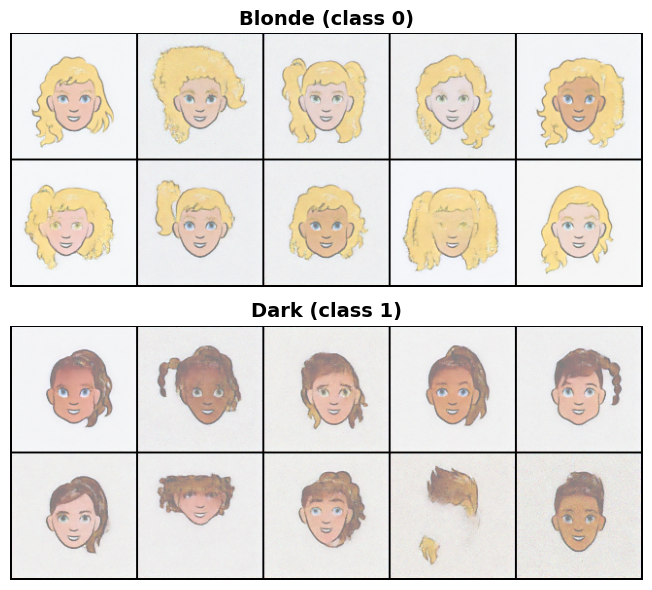

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 1, figsize=(15, 6))

blonde_grid = mpimg.imread('./generated/blonde_final.png')
dark_grid   = mpimg.imread('./generated/dark_final.png')

axes[0].imshow(blonde_grid)
axes[0].set_title('Blonde (class 0)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(dark_grid)
axes[1].set_title('Dark (class 1)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./generated/comparison.png', dpi=150, bbox_inches='tight')
plt.show()